# 1. Introduction

## Objective

Previous notebooks evaluated the overall impact of moving the progression gate from Level 30 to Level 40.

This notebook investigates whether the treatment affected different types of players differently by segmenting users based on their gameplay activity.

Segmentation analysis helps identify which player groups benefited most or were most negatively affected by the experimental change.

# 2. Why Segmentation Matters

## Objective

Player populations are rarely homogeneous.

A feature that improves retention for highly engaged players may have little or even negative impact on casual players.

Segmenting players allows us to understand how different user groups respond to product changes and supports more targeted product decisions.

# 3. Player Segmentation

## 3.1 Objective

Divide players into engagement-based segments using the total number of game rounds played.

Segmentation enables comparison of retention performance across different levels of player engagement.

## 3.2 Create Player Segments

Classify players into Low, Medium, and High engagement groups based on the distribution of total game rounds played.

Quantile-based segmentation ensures that each group contains approximately one-third of the players.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from scipy.stats import chisquare

In [2]:
df = pd.read_csv("../data/cleaned/cookie_cats_cleaned.csv")

In [4]:
df["engagement_segment"] = pd.qcut(
    df["sum_gamerounds"],
    q=3,
    labels=[
        "Low",
        "Medium",
        "High"
    ]
)

df["engagement_segment"].value_counts()

engagement_segment
Low       32224
High      29575
Medium    28390
Name: count, dtype: int64

## 3.3 Verify the Segmentation

Review the number of players in each engagement segment to ensure that the quantile-based segmentation produced balanced groups suitable for comparison.

In [5]:
segment_summary = (
    df["engagement_segment"]
    .value_counts()
    .sort_index()
    .rename_axis("Segment")
    .reset_index(name="Players")
)

segment_summary

,Segment,Players
0,Low,32224
1,Medium,28390
2,High,29575


## 3.4 Interpretation

### Results

| Segment | Players |
|----------|---------:|
| Low | 32,224 |
| Medium | 28,390 |
| High | 29,575 |

### Key Insights

- The dataset was successfully divided into three engagement segments.
- Segment sizes are reasonably balanced, providing sufficient observations for reliable comparisons.
- Small differences in segment size are expected because many players share identical values for total game rounds.

### Business Perspective

Segmenting players by engagement enables a more detailed understanding of how different user groups responded to the experiment. This allows product decisions to be tailored to specific player behaviors rather than relying solely on overall averages.

# 4. Segment-wise Retention Analysis

## 4.1 One-Day Retention

Calculate the one-day retention rate for each engagement segment and compare the performance of the two experiment groups.

In [6]:
segment_retention_1 = (
    df.groupby(["engagement_segment", "version"], observed=True)["retention_1"]
      .mean()
      .mul(100)
      .round(2)
      .unstack()
)

segment_retention_1

version,gate_30,gate_40
engagement_segment,,
Low,9.50,9.76
Medium,45.23,44.65
High,82.33,81.95


## 4.2 Visualize One-Day Retention

Visualize one-day retention across engagement segments for both experiment groups.

The chart highlights how player engagement influences short-term retention and whether the treatment effect varies across segments.

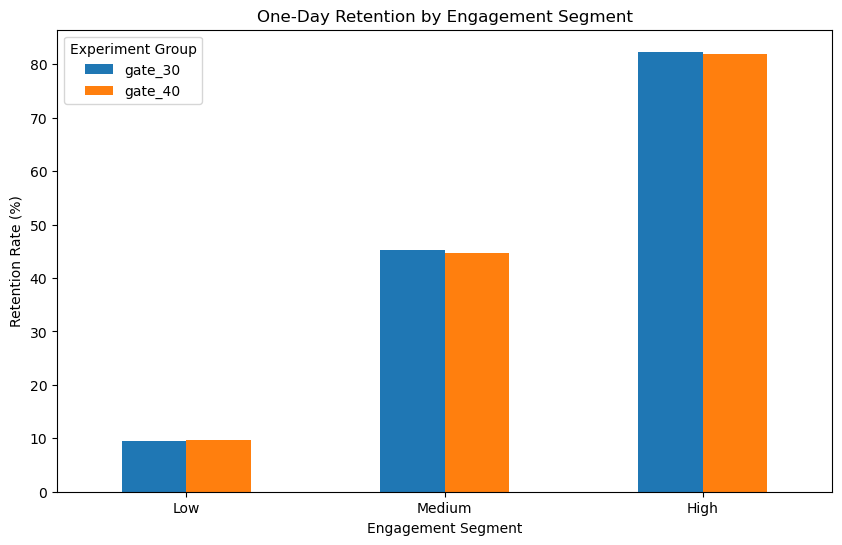

In [7]:
segment_retention_1.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("One-Day Retention by Engagement Segment")
plt.xlabel("Engagement Segment")
plt.ylabel("Retention Rate (%)")
plt.xticks(rotation=0)
plt.legend(title="Experiment Group")

plt.show()

## 4.3 Interpretation

### Key Insights

- One-day retention increases substantially as player engagement increases.
- The Low engagement segment shows a small advantage for **gate_40**.
- The Medium and High engagement segments show slightly higher retention for **gate_30**.
- The observed differences are relatively small and require statistical testing before drawing conclusions.

### Business Perspective

Player engagement has a much stronger influence on one-day retention than the gate placement itself. While gate placement may have a modest effect, overall engagement level remains the primary driver of early player retention.

## 4.4 Seven-Day Retention

Calculate the seven-day retention rate for each engagement segment and compare the performance of the two experiment groups.

In [8]:
segment_retention_7 = (
    df.groupby(["engagement_segment", "version"], observed=True)["retention_7"]
      .mean()
      .mul(100)
      .round(2)
      .unstack()
)

segment_retention_7

version,gate_30,gate_40
engagement_segment,,
Low,1.54,1.64
Medium,8.68,7.97
High,47.66,46.38


## 4.5 Visualize Seven-Day Retention

Visualize the seven-day retention rate across engagement segments for both experiment groups.

The chart illustrates how the long-term impact of the progression gate varies across different levels of player engagement.

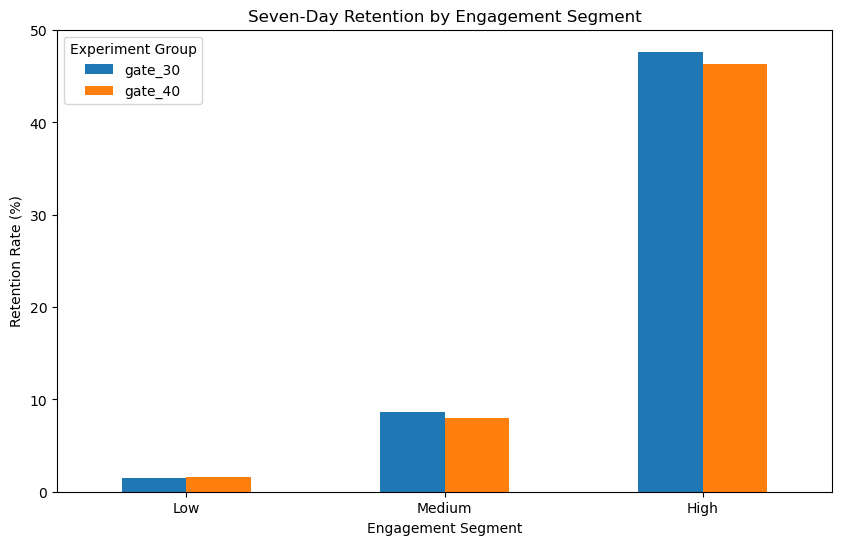

In [9]:
segment_retention_7.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Seven-Day Retention by Engagement Segment")

plt.xlabel("Engagement Segment")

plt.ylabel("Retention Rate (%)")

plt.xticks(rotation=0)

plt.legend(title="Experiment Group")

plt.show()

## 4.6 Interpretation

### Key Insights

- Seven-day retention increases substantially with player engagement.
- The Low engagement segment shows nearly identical retention across both experiment groups.
- The Medium engagement segment demonstrates a modest advantage for **gate_30**.
- The High engagement segment exhibits the largest improvement for **gate_30**, indicating that highly engaged players are more sensitive to the progression gate.

### Business Perspective

The experimental effect appears to become stronger as player engagement increases. While casual players show little response to the treatment, highly engaged players benefit more from keeping the progression gate at Level 30, suggesting that progression design has a greater influence on long-term retention for active players.

## 4.7 Combined Retention Summary

Compare one-day and seven-day retention across engagement segments to identify consistent patterns in player behavior.

In [10]:
comparison = pd.DataFrame({
    "1-Day Gate30": segment_retention_1["gate_30"],
    "1-Day Gate40": segment_retention_1["gate_40"],
    "7-Day Gate30": segment_retention_7["gate_30"],
    "7-Day Gate40": segment_retention_7["gate_40"]
})

comparison

,1-Day Gate30,1-Day Gate40,7-Day Gate30,7-Day Gate40
engagement_segment,,,,
Low,9.50,9.76,1.54,1.64
Medium,45.23,44.65,8.68,7.97
High,82.33,81.95,47.66,46.38


# 5. Segment-wise Statistical Analysis

## 5.1 Objective

Perform separate hypothesis tests for each engagement segment to determine whether the observed retention differences are statistically significant.

This analysis identifies which player segments contribute most to the overall experimental effect.

## 5.2 Theory

The overall A/B test measures the average treatment effect across all players.

However, different player segments may respond differently to the same product change.

By performing separate hypothesis tests for each engagement segment, we can identify whether the treatment effect is consistent or concentrated within specific groups.

Each segment is analyzed independently using a two-proportion Z-test.

## 5.3 Seven-Day Retention by Engagement Segment

Perform independent hypothesis tests for each engagement segment using seven-day retention.

For each segment:

- Calculate retention rates.
- Perform a two-proportion Z-test.
- Report the p-value.
- Determine whether the observed difference is statistically significant.

In [11]:
from statsmodels.stats.proportion import proportions_ztest

results = []

segments = ["Low", "Medium", "High"]

for segment in segments:

    temp = df[df["engagement_segment"] == segment]

    summary = temp.groupby("version")["retention_7"].agg(
        retained="sum",
        total="count"
    )

    counts = summary["retained"].values
    totals = summary["total"].values

    z_stat, p_value = proportions_ztest(
        counts,
        totals
    )

    results.append({
        "Segment": segment,
        "Gate30 Retention (%)":
            round(
                summary.loc["gate_30", "retained"] /
                summary.loc["gate_30", "total"] * 100,
                2
            ),
        "Gate40 Retention (%)":
            round(
                summary.loc["gate_40", "retained"] /
                summary.loc["gate_40", "total"] * 100,
                2
            ),
        "Z Statistic": round(z_stat, 3),
        "P Value": round(p_value, 4),
        "Significant?":
            "Yes" if p_value < 0.05 else "No"
    })

segment_results = pd.DataFrame(results)

segment_results

,Segment,Gate30 Retention (%),Gate40 Retention (%),Z Statistic,P Value,Significant?
0,Low,1.54,1.64,-0.680,0.4965,No
1,Medium,8.68,7.97,2.152,0.0314,Yes
2,High,47.66,46.38,2.200,0.0278,Yes


## 5.4 Interpretation

### Results

| Segment | P-value | Significant |
|----------|---------|-------------|
| Low | 0.4965 | No |
| Medium | 0.0314 | Yes |
| High | 0.0278 | Yes |

### Key Insights

- The Low engagement segment showed no statistically significant difference between the two gate placements.
- The Medium engagement segment demonstrated a significant improvement in seven-day retention for **gate_30**.
- The High engagement segment also showed a significant retention advantage for **gate_30**.
- The treatment effect becomes stronger as player engagement increases.

### Business Perspective

The progression gate has little influence on casual players but has a measurable positive impact on medium and highly engaged players. These findings suggest that the overall improvement in seven-day retention is primarily driven by players who spend more time progressing through the game.

## 5.5 Visual Summary

Compare seven-day retention across engagement segments for both experiment groups.

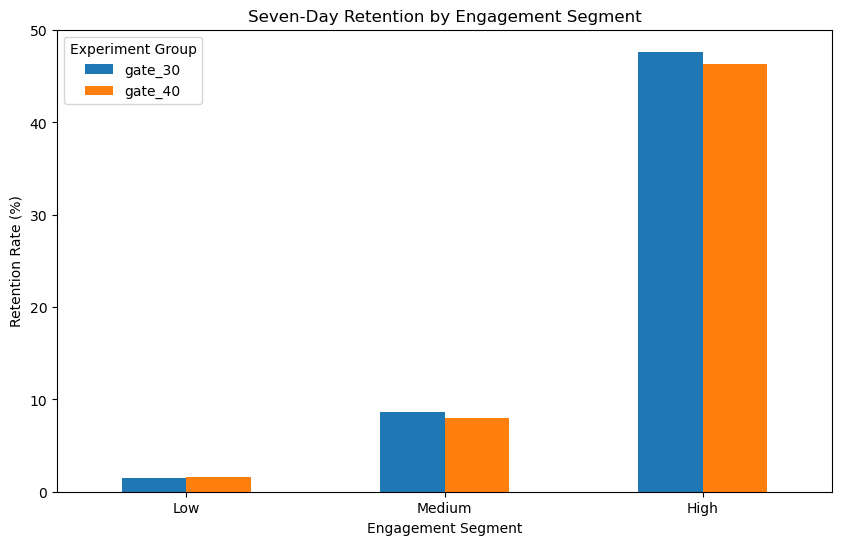

In [12]:
segment_retention_7.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Seven-Day Retention by Engagement Segment")

plt.xlabel("Engagement Segment")

plt.ylabel("Retention Rate (%)")

plt.xticks(rotation=0)

plt.legend(title="Experiment Group")

plt.show()

# 6. Business Insights

## Key Findings

- Overall seven-day retention was higher for **gate_30**.
- The improvement was concentrated among Medium and High engagement players.
- Low engagement players showed no meaningful response to the gate placement.
- Highly engaged players experienced the largest improvement, suggesting that progression design has a greater influence on long-term player retention than on early retention.

# 7. Recommendations

## Recommendations

Based on the segmentation analysis, the following recommendations are proposed:

- Retain the progression gate at **Level 30** to maximize long-term player retention.
- Prioritize engagement strategies for Low engagement players, as gate placement alone does not significantly affect their retention.
- Continue monitoring retention separately across different player segments in future experiments.
- Incorporate segmentation into future A/B testing workflows to identify heterogeneous treatment effects rather than relying solely on overall averages.

# 8. Key Takeaways

## Summary

- Player engagement strongly influences both one-day and seven-day retention.
- The positive effect of **gate_30** is concentrated among Medium and High engagement players.
- Casual players exhibit similar retention regardless of gate placement.
- Segment-level analysis reveals insights that are not apparent from overall experiment results.

## Final Conclusion

The segmentation analysis demonstrates that the overall improvement in seven-day retention is primarily driven by players with higher engagement levels. Maintaining the progression gate at **Level 30** provides the greatest long-term benefit for active players while having minimal impact on casual users.